# Spectral fitting example (AGN)

**To run this, you need the following files, which can be downloaded using the first few cells of this notebook:**
- orientation file (20280301_3_month_with_orbital_info.ori)       
- binned data (NGC4151_ec200_bkg_binned_data.hdf5, NGC4151_ec200_binned_data.hdf5, & bkg_binned_data.hdf5)     
- detector response (SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5.zip)     

**The binned data are simulations of the NGC4151_ec200 Nebula and albedo photon background produced using the COSI SMEX mass model. The detector response needs to be unzipped before running the notebook.**

This notebook fits the spectrum of a NGC4151_ec200 simulated using MEGAlib and combined with background.

[3ML](https://threeml.readthedocs.io/) is a high-level interface that allows multiple datasets from different instruments to be used coherently to fit the parameters of source model. A source model typically consists of a list of sources with parametrized spectral shapes, sky locations and, for extended sources, shape. Polarization is also possible. A "coherent" analysis, in this context, means that the source model parameters are fitted using all available datasets simultanously, rather than performing individual fits and finding a well-suited common model a posteriori. 

In order for a dataset to be included in 3ML, each instrument needs to provide a "plugin". Each plugin is responsible for reading the data, convolving the source model (provided by 3ML) with the instrument response, and returning a likelihood. In our case, we'll compute a binned Poisson likelihood:

$$
\log \mathcal{L}(\mathbf{x}) = \sum_i \log \frac{\lambda_i(\mathbf{x})^{d_i} \exp (-\lambda_i)}{d_i!}
$$

where $d_i$ are the counts on each bin and $\lambda_i$ are the expected counts given a source model with parameters $\mathbf{x}$. 

In this example, we will fit a single point source with a known location. We'll assume the background is known and fixed up to a scaling factor. Finally, we will fit a Band function:

$$
f(x) = K \begin{cases} \left(\frac{x}{E_{piv}}\right)^{\alpha} \exp \left(-\frac{(2+\alpha)
       * x}{x_{p}}\right) & x \leq (\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \\ \left(\frac{x}{E_{piv}}\right)^{\beta}
       * \exp (\beta-\alpha)\left[\frac{(\alpha-\beta) x_{p}}{E_{piv}(2+\alpha)}\right]^{\alpha-\beta}
       * &x>(\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \end{cases}
$$

where $K$ (normalization), $\alpha$ & $\beta$ (spectral indeces), and $x_p$ (peak energy) are the free parameters, while $E_{piv}$ is the pivot energy which is fixed (and arbitrary).

Considering these assumptions:

$$
\lambda_i(\mathbf{x}) = B*b_i + s_i(\mathbf{x})
$$

where $B*b_i$ are the estimated counts due to background in each bin with $B$ the amplitude and $b_i$ the shape of the background, and $s_i$ are the corresponding expected counts from the source, the goal is then to find the values of $\mathbf{x} = [K, \alpha, \beta, x_p]$ and $B$ that maximize $\mathcal{L}$. These are the best estimations of the parameters.

The final module needs to also fit the time-dependent background, handle multiple point-like and extended sources, as well as all the spectral models supported by 3ML. Eventually, it will also fit the polarization angle. However, this simple example already contains all the necessary pieces to do a fit.

In [42]:
from cosipy import COSILike
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()


from pathlib import Path

import os

%matplotlib inline

## Download and read in binned data

Define the path to the directory containing the data, detector response, orientation file, and yaml files if they have already been downloaded, or the directory to download the files into

In [43]:
data_path = Path("/Users/parshadkp/Software/COSI_Data/")

Read in the spacecraft orientation file

In [44]:
# sc_orientation = SpacecraftFile.parse_from_file(data_path / "DC2_Files/20280301_3_month_with_orbital_info.ori") #DC?2
sc_orientation = SpacecraftFile.parse_from_file(data_path / "DC3_Files/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori") #DC3

In [45]:
# dr = str(data_path / "DC2_Files/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5") # DC2
dr = str(data_path / "DC3_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse_nside8.area.good_chunks.h5") # DC3

# XRay Analysis

## BAT Analysis

13:27:37 INFO      Auto-probed noise models:                                                    ]8;id=635284;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=988548;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: gaussian                                                      ]8;id=755479;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=685922;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: None                                                           ]8;id=446176;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=852733;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=203579;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=497705;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#1247\1247]8;;\


WARNING UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.



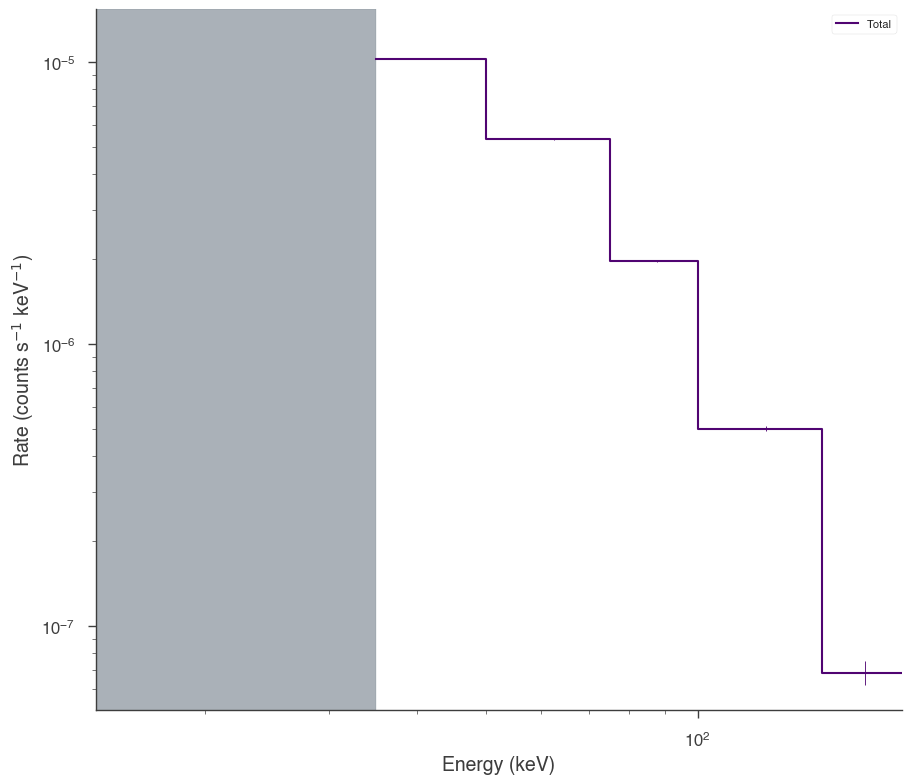

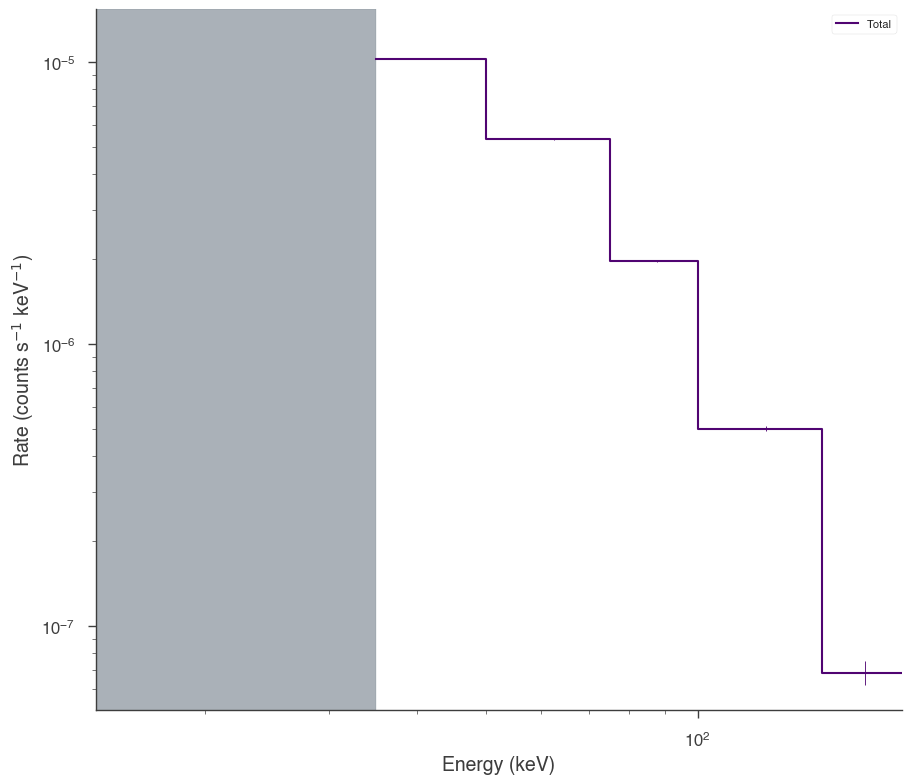

In [6]:
bat_rsp = "/Users/parshadkp/Software/COSI_Data/AGN_Data/XRay/swiftbat_survey_full.rsp"
bat_pha = "/Users/parshadkp/Software/COSI_Data/AGN_Data/XRay/SWIFT_J1210.5+3924_resp.pha"

# bat_rsp = data_path/"AGN_Data/XRay/BAT_157m_swiftbat_survey_full_157m.rsp"
# bat_pha = data_path/"AGN_Data/XRay/simulate_bat_ec_1000_gamma_1dot75.pha"

bat = OGIPLike("BAT", observation=bat_pha, response=bat_rsp)

bat.set_active_measurements("40-200")
bat.view_count_spectrum()

## NuStar Analysis

17:48:48 INFO      Auto-probed noise models:                                                    ]8;id=811656;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=207123;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: poisson                                                       ]8;id=606343;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=48647;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: poisson                                                        ]8;id=22116;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=253378;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

         INFO      Range 20-79 translates to channels 459-1934                                 ]8;id=854172;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=839916;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#1247\1247]8;;\

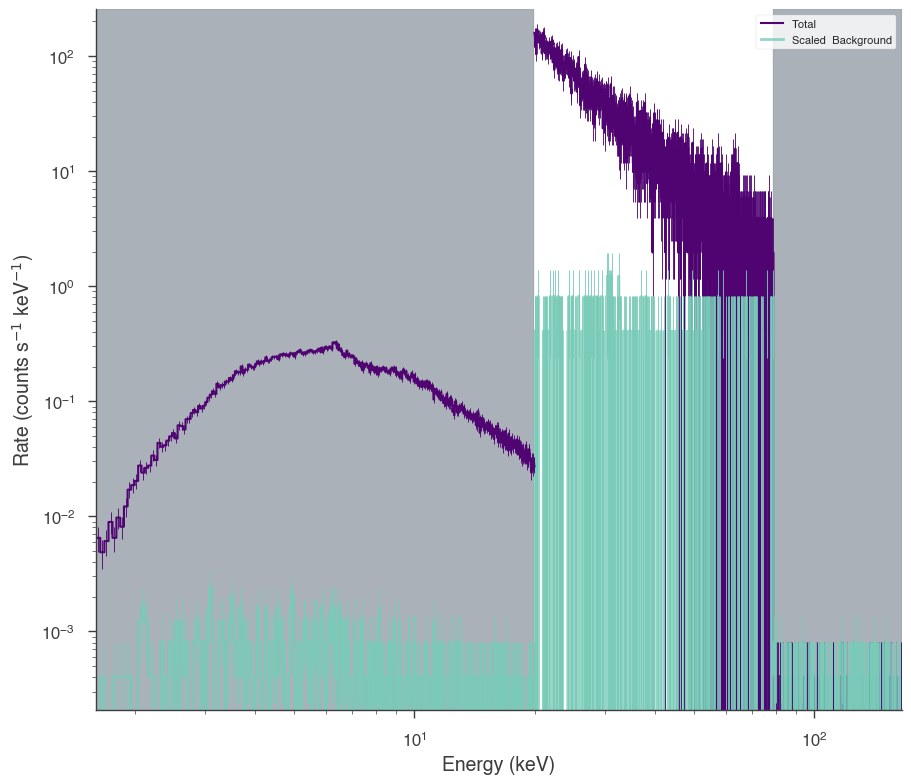

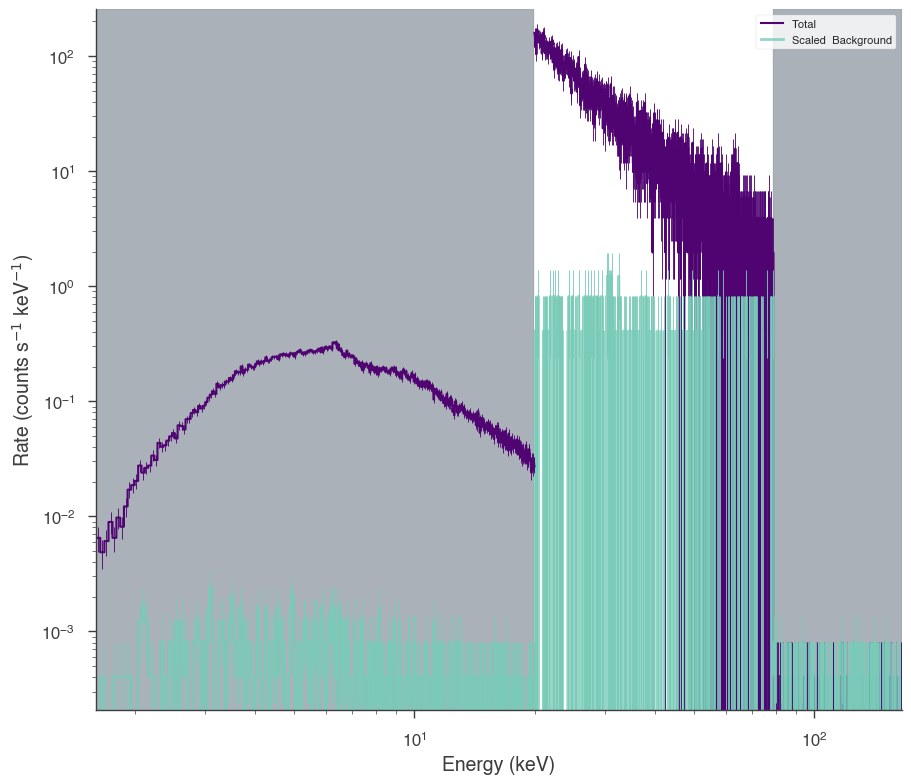

In [9]:
# Use the NuSTAR PHA, RMF, and ARF files
nustar_fpma = OGIPLike("nustar_fpma", observation=data_path/"AGN_Data/XRay/nu60001111005A01_sr.pha", background=data_path/"AGN_Data/XRay/nu60001111005A01_bk.pha", response=data_path/"AGN_Data/XRay/nu60001111005A01_sr.rmf", arf_file=data_path/"AGN_Data/XRay/nu60001111005A01_sr.arf")

nustar_fpma.set_active_measurements("20-79")
nustar_fpma.view_count_spectrum()

17:48:58 INFO      Auto-probed noise models:                                                    ]8;id=550461;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=604114;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: poisson                                                       ]8;id=318955;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=696693;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: poisson                                                        ]8;id=6362;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=704011;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

         INFO      Range 20-79 translates to channels 459-1934                                 ]8;id=753240;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=666588;file:///Users/parshadkp/.pyenv/versions/3.10.0/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#1247\1247]8;;\

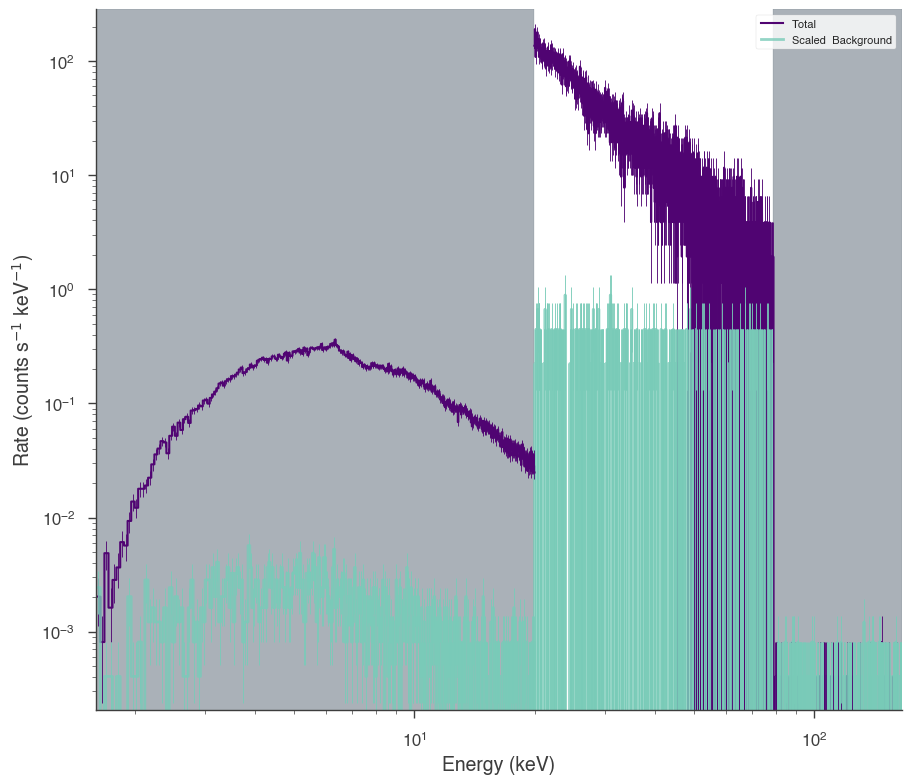

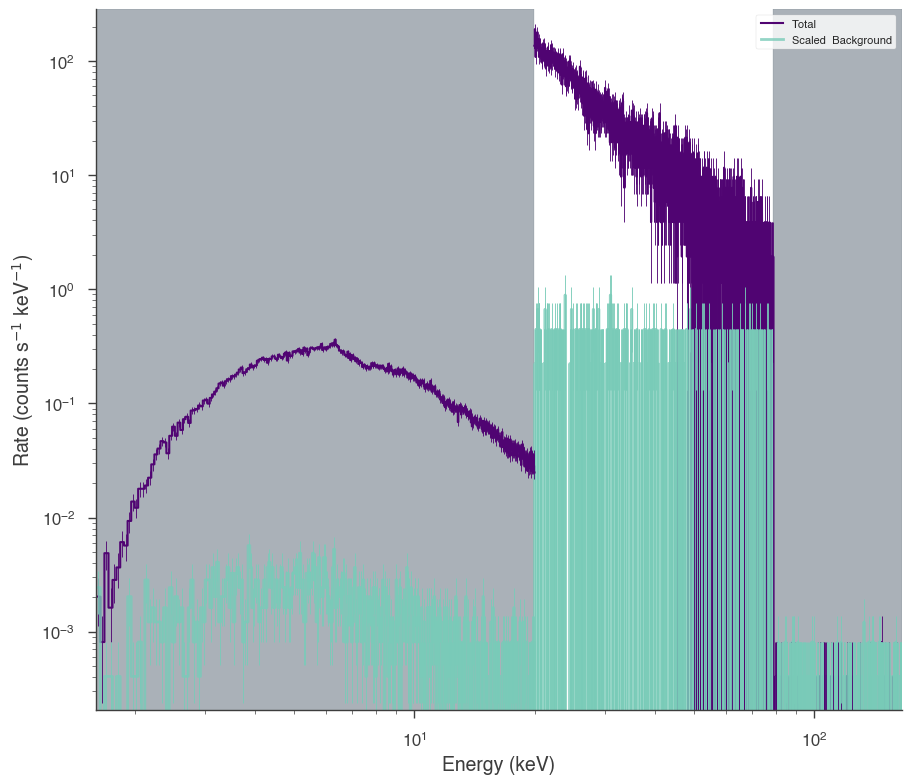

In [10]:
nustar_fpmb = OGIPLike("nustar_fpmb", observation=data_path/"AGN_Data/XRay/nu60001111005B01_sr.pha", background=data_path/"AGN_Data/XRay/nu60001111005B01_bk.pha", response=data_path/"AGN_Data/XRay/nu60001111005B01_sr.rmf", arf_file=data_path/"AGN_Data/XRay/nu60001111005B01_sr.arf")
nustar_fpmb.set_active_measurements("20-79")
nustar_fpmb.view_count_spectrum()

# COSI Analysis

Load binned .hdf5 files

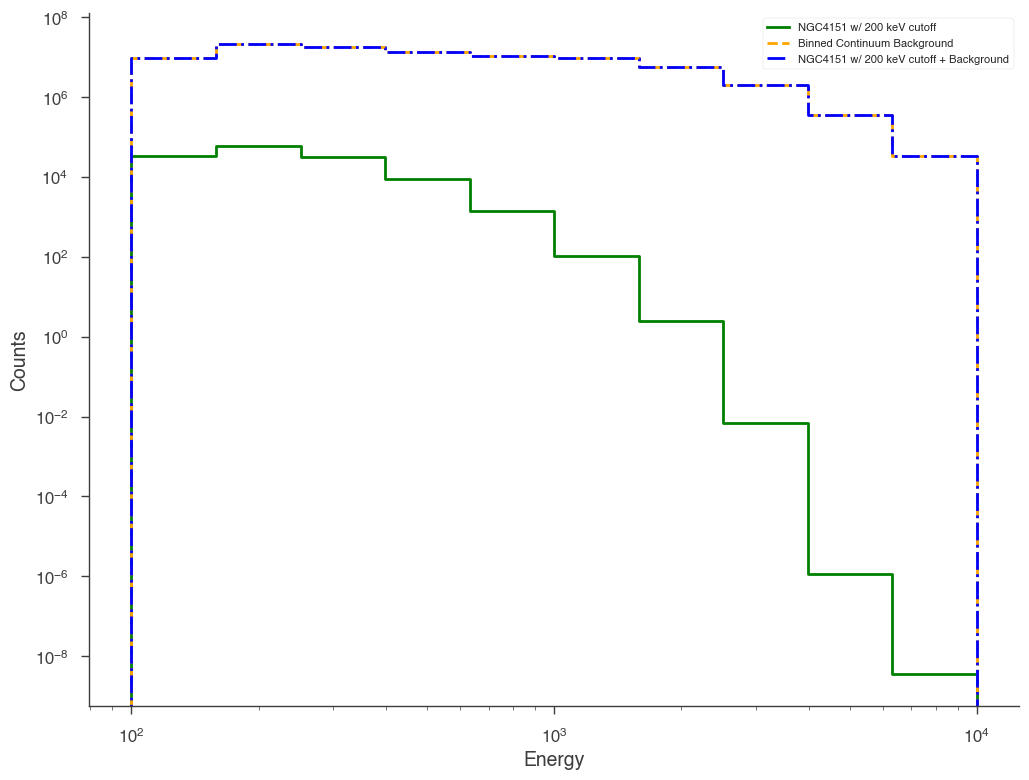

In [46]:
# time_cut = 0.0960
multiplier = 2

# NGC4151_ec200 = Histogram.open(data_path / "AGN_Data/GammaRay/DC3/NGC_4151_ec200_DC3_corrected_COSI.hdf5")*multiplier
# bkg = Histogram.open(data_path / "DC3_Files/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5")*multiplier
# NGC4151_ec200_bkg = Histogram.open(data_path / "AGN_Data/GammaRay/DC3/NGC_4151_ec200_DC3_bkg_COSI.hdf5")*multiplier

NGC4151_ec200 = Histogram.open(data_path / "AGN_Data/GammaRay/DC3/NGC_4151_ec200_DC3_corrected_COSI.hdf5")*multiplier
bkg = Histogram.open(data_path /  "AGN_Data/GammaRay/DC3/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut_NGC4151_TimeCut.hdf5")*multiplier
NGC4151_ec200_bkg = Histogram.open(data_path / "AGN_Data/GammaRay/DC3/NGC_4151_ec200_Totalbkg_COSI_TimeCut.hdf5")*multiplier

fig, ax = plt.subplots(figsize=(12, 9))
NGC4151_ec200.project("Em").draw(ax, label="NGC4151 w/ 200 keV cutoff", color="green")
bkg.project("Em").draw(ax, label="Binned Continuum Background", color="orange", linestyle="dashed")
NGC4151_ec200_bkg.project("Em").draw(ax, label="NGC4151 w/ 200 keV cutoff + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

# ax.set_ylim(1e0, 1e8)
ax.set_ylabel("Counts")
ax.set_xlabel("Energy")
plt.legend()

Define the path to the detector response

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [47]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

Define a point source at the known location with a Band function spectrum and add it to the model. The initial values of the Band function parameters are set to the true values used to simulate the source

### Powerlaw with energy cutoff fit

In [48]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 0.1 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = 10. * u.keV
index = -1.75

spectrum = Cutoff_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xc.value = xc.value
spectrum.index.value = index
spectrum.index.fix = True

# Harsher Parameters
spectrum.K.min_value = 1e-4
spectrum.K.max_value = 2
spectrum.xc.min_value = 1
spectrum.xc.max_value = 10000
# spectrum.index.min_value = -3
# spectrum.index.max_value = 1

spectrum.K.delta = 0.05
spectrum.xc.delta = 10
spectrum.index.delta = 0.25

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xc.unit = xc.unit

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit

In [49]:
# bat.use_effective_area_correction(0.2, 1.8)
# plugins = DataList(bat, cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)
# nustar_fpma.use_effective_area_correction(0.2, 1.8)
# nustar_fpmb.use_effective_area_correction(0.2, 1.8)
# plugins = DataList(cosi, nustar_fpma, nustar_fpmb)
# plugins = DataList(cosi, bat, nustar_fpma, nustar_fpmb)
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit() #increase number of samples?

23:19:48 INFO      set the minimizer to minuit                                             ]8;id=412647;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=165147;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(2.66 -0.30 +0.34) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.xc,(2.01 -0.21 +0.23) x 10^2,keV
background_cosi,1.00000 +/- 0.00013,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-5.166485e+08
total,-5.166485e+08


Values of statistical measures:

,statistical measures
AIC,-1.033297e+09
BIC,-1.033297e+09


(                                             value  negative_error  \
 source.spectrum.main.Cutoff_powerlaw.K     0.26560       -0.030419   
 source.spectrum.main.Cutoff_powerlaw.xc  200.99209      -21.395286   
 background_cosi                            1.00000       -0.000129   
 
                                          positive_error      error  \
 source.spectrum.main.Cutoff_powerlaw.K         0.034174   0.032296   
 source.spectrum.main.Cutoff_powerlaw.xc       24.291642  22.843464   
 background_cosi                                0.000128   0.000128   
 
                                                     unit  
 source.spectrum.main.Cutoff_powerlaw.K   1 / (keV s cm2)  
 source.spectrum.main.Cutoff_powerlaw.xc              keV  
 background_cosi                                           ,
        -log(likelihood)
 cosi      -5.166485e+08
 total     -5.166485e+08)

## Error propagation and plotting (Cutoff powerlaw function)

Define Band function spectrum injected into MEGAlib

In [50]:
K_inj = 0.15*multiplier / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

The summary of the results above tell you the optimal values of the parameters, as well as the errors. Propogate the errors to the "evaluate_at" method of the spectrum

In [51]:
results_ec200 = like.results

print(results_ec200.display())

parameters = {par.name:results_ec200.get_variates(par.path)
              for par in results_ec200.optimized_model["source"].parameters.values()
              if par.free}

results_ec200_err = results_ec200.propagate(results_ec200.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results_ec200.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(2.66 -0.30 +0.34) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.xc,(2.01 -0.21 +0.23) x 10^2,keV
background_cosi,1.00000 +/- 0.00013,


Correlation matrix:

1.00,-0.92,0.04
-0.92,1.00,-0.27
0.04,-0.27,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-5.166485e+08
total,-5.166485e+08


Values of statistical measures:

,statistical measures
AIC,-1.033297e+09
BIC,-1.033297e+09


None
  * source (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 0.2656001176767887
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 0.0001
            * max_value: 2.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.75
            * desc

Evaluate the flux and errors at a range of energies for the fitted and injected spectra, and the simulated source flux

In [52]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_lo_ec200 = np.zeros_like(energy)
flux_median_ec200 = np.zeros_like(energy)
flux_hi_ec200 = np.zeros_like(energy)
flux_inj_ec200 = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_ec200 = results_ec200_err(e)
    flux_median_ec200[i] = flux_ec200.median
    flux_lo_ec200[i], flux_hi_ec200[i] = flux_ec200.equal_tail_interval(cl=0.68)
    flux_inj_ec200[i] = spectrum_inj_ec200.evaluate_at(e)

Plot the fitted and injected spectra

# NGC 4151 with 1000 keV cutoff.

13:29:33 INFO      Auto-probed noise models:                                                    ]8;id=677571;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=728535;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: gaussian                                                      ]8;id=681026;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=380661;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: None                                                           ]8;id=189635;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=239018;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=500538;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=159590;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#1247\1247]8;;\


WARNING UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.



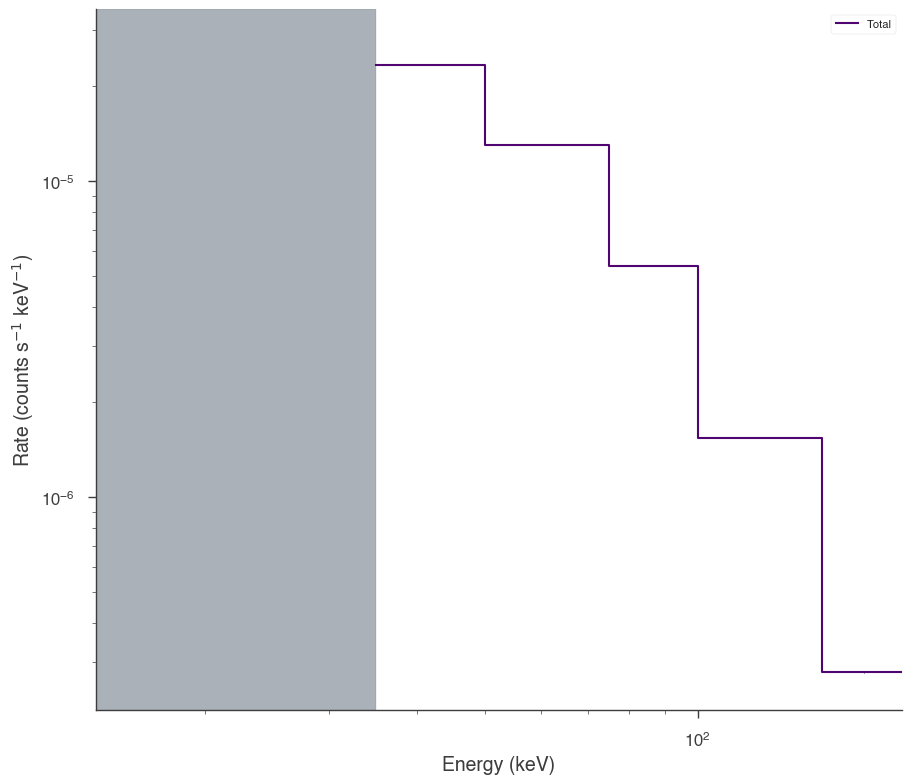

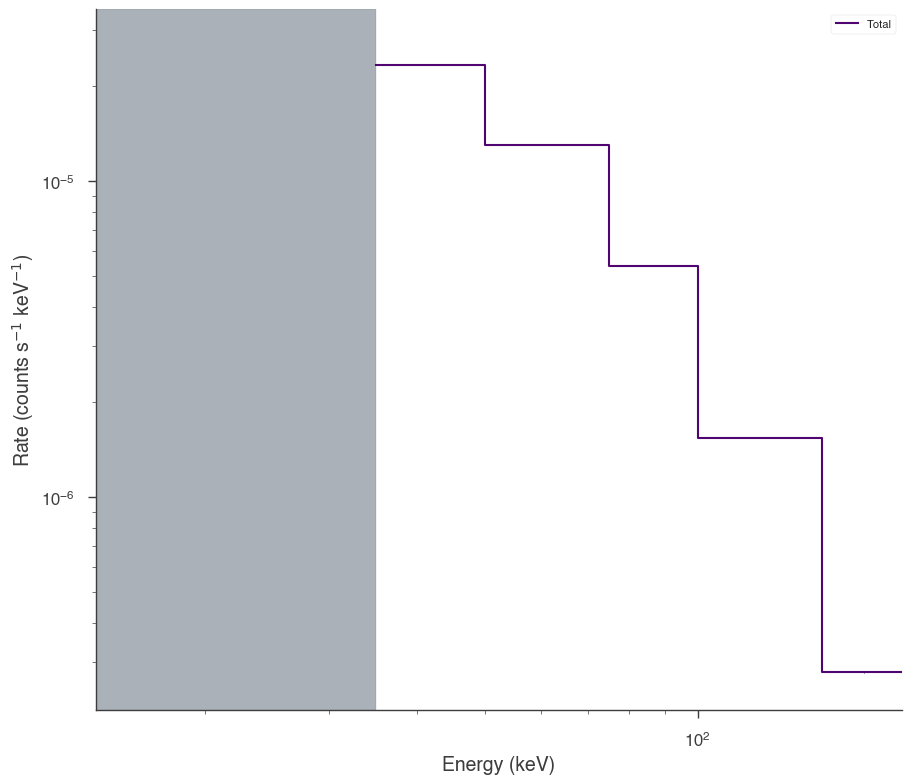

In [14]:
bat_rsp = data_path/"AGN_Data/XRay/Simulations/BAT_157m_swiftbat_survey_full_157m.rsp"
bat_pha = data_path/"AGN_Data/XRay/Simulations/simulate_bat_ec_1000_gamma_1dot75.pha"

bat = OGIPLike("BAT", observation=bat_pha, response=bat_rsp)

bat.set_active_measurements("40-200")
bat.view_count_spectrum()

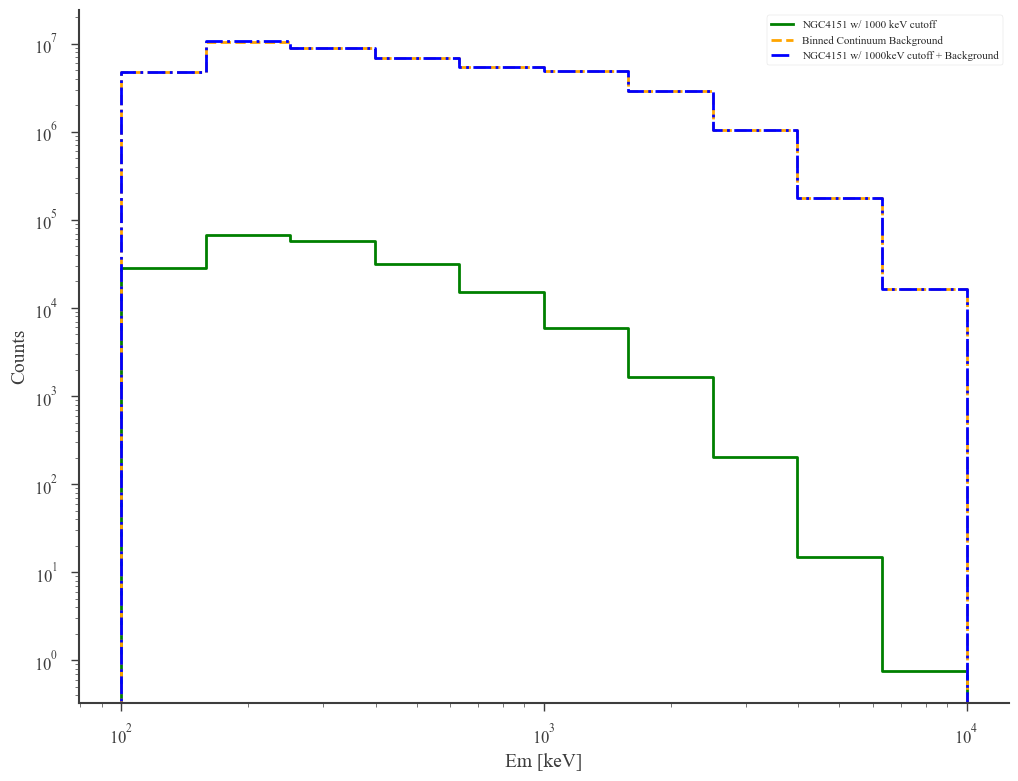

In [70]:
multiplier = 1

# NGC4151_ec1000 = Histogram.open(data_path / "AGN_Data/GammaRay/DC3/NGC_4151_ec1000_DC3_corrected_COSI.hdf5")
# bkg = Histogram.open(data_path / "DC3_Files/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5")
# NGC4151_ec1000_bkg = Histogram.open(data_path / "AGN_Data/GammaRay/DC3/NGC_4151_ec1000_DC3_bkg_COSI.hdf5")

NGC4151_ec1000 = Histogram.open(data_path / "AGN_Data/GammaRay/DC3/NGC_4151_ec1000_DC3_corrected_COSI.hdf5")*multiplier
bkg = Histogram.open(data_path /  "AGN_Data/GammaRay/DC3/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut_NGC4151_TimeCut.hdf5")*multiplier
NGC4151_ec1000_bkg = Histogram.open(data_path / "AGN_Data/GammaRay/DC3/NGC_4151_ec1000_Totalbkg_COSI_TimeCut.hdf5")*multiplier

fig, ax = plt.subplots(figsize=(12, 9))
NGC4151_ec1000.project("Em").draw(ax, label="NGC4151 w/ 1000 keV cutoff", color="green")
bkg.project("Em").draw(ax, label="Binned Continuum Background", color="orange", linestyle="dashed")
NGC4151_ec1000_bkg.project("Em").draw(ax, label="NGC4151 w/ 1000keV cutoff + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

# ax.set_ylim(1e0, 1e8)
ax.set_ylabel("Counts")
plt.legend()

In [71]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec1000_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

In [72]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 0.1 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = 100. * u.keV
index = -1.75

spectrum = Cutoff_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xc.value = xc.value
spectrum.index.value = index

# Harsher Parameters
spectrum.K.min_value = 1e-4
spectrum.K.max_value = 1
spectrum.xc.min_value = 100 # keep these relatively the same
spectrum.xc.max_value = 10000 # change to 1000
spectrum.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = 1

spectrum.K.delta = 0.05
spectrum.xc.delta = 10
spectrum.index.delta = 0.15

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xc.unit = xc.unit

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

In [73]:
# nustar_fpma.use_effective_area_correction(0.1, 1.8)
# nustar_fpmb.use_effective_area_correction(0.1, 1.8)
# bat.use_effective_area_correction(0.1, 1.8)
# plugins = DataList(bat, cosi)
# plugins = DataList(nustar_fpma, nustar_fpmb, cosi)
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit() #increase number of samples?

16:59:13 INFO      set the minimizer to minuit                                             ]8;id=71085;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=540586;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(1.26 -0.27 +0.34) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.75 +/- 0.05,
source.spectrum.main.Cutoff_powerlaw.xc,(1.02 -0.17 +0.20) x 10^3,keV
background_cosi,(10.0000 +/- 0.0021) x 10^-1,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.275248e+08
total,-2.275248e+08


Values of statistical measures:

,statistical measures
AIC,-4.550496e+08
BIC,-4.550496e+08


(                                                  value  negative_error  \
 source.spectrum.main.Cutoff_powerlaw.K         0.126015       -0.026365   
 source.spectrum.main.Cutoff_powerlaw.index    -1.754409       -0.049027   
 source.spectrum.main.Cutoff_powerlaw.xc     1017.822261     -168.789112   
 background_cosi                                0.999996       -0.000203   
 
                                             positive_error       error  \
 source.spectrum.main.Cutoff_powerlaw.K            0.033585    0.029975   
 source.spectrum.main.Cutoff_powerlaw.index        0.047856    0.048441   
 source.spectrum.main.Cutoff_powerlaw.xc         197.983013  183.386063   
 background_cosi                                   0.000210    0.000206   
 
                                                        unit  
 source.spectrum.main.Cutoff_powerlaw.K      1 / (keV s cm2)  
 source.spectrum.main.Cutoff_powerlaw.index                   
 source.spectrum.main.Cutoff_powerlaw.xc            

In [76]:
K_inj = 0.15*multiplier / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

In [77]:
results_ec1000 = like.results

print(results_ec1000.display())

parameters = {par.name:results_ec1000.get_variates(par.path)
              for par in results_ec1000.optimized_model["source"].parameters.values()
              if par.free}

results_ec1000_err = results_ec1000.propagate(results_ec1000.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results_ec1000.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(1.26 -0.27 +0.34) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.75 +/- 0.05,
source.spectrum.main.Cutoff_powerlaw.xc,(1.02 -0.17 +0.20) x 10^3,keV
background_cosi,(10.0000 +/- 0.0021) x 10^-1,


Correlation matrix:

1.00,-0.98,0.65,-0.16
-0.98,1.00,-0.76,0.14
0.65,-0.76,1.00,-0.30
-0.16,0.14,-0.30,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.275248e+08
total,-2.275248e+08


Values of statistical measures:

,statistical measures
AIC,-4.550496e+08
BIC,-4.550496e+08


None
  * source (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 0.12601511279845787
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 0.0001
            * max_value: 1.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.75440924515665
     

In [78]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_ec1000 = results_ec1000_err(e)
    flux_median_ec1000[i] = flux_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_ec1000.equal_tail_interval(cl=0.68)
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)

# NGC 1068 200 keV Cutoff

Create BinnedData objects for the NGC1068_ec200 only, NGC1068_ec200+background, and background only. The NGC4151_ec200 only simulation is not used for the spectral fit, but can be used to compare the fitted spectrum to the source simulation

13:32:14 INFO      Auto-probed noise models:                                                    ]8;id=658749;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=908393;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: gaussian                                                      ]8;id=898880;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=932075;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: None                                                           ]8;id=121168;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=502219;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=265413;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=168283;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#1247\1247]8;;\


WARNING UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.



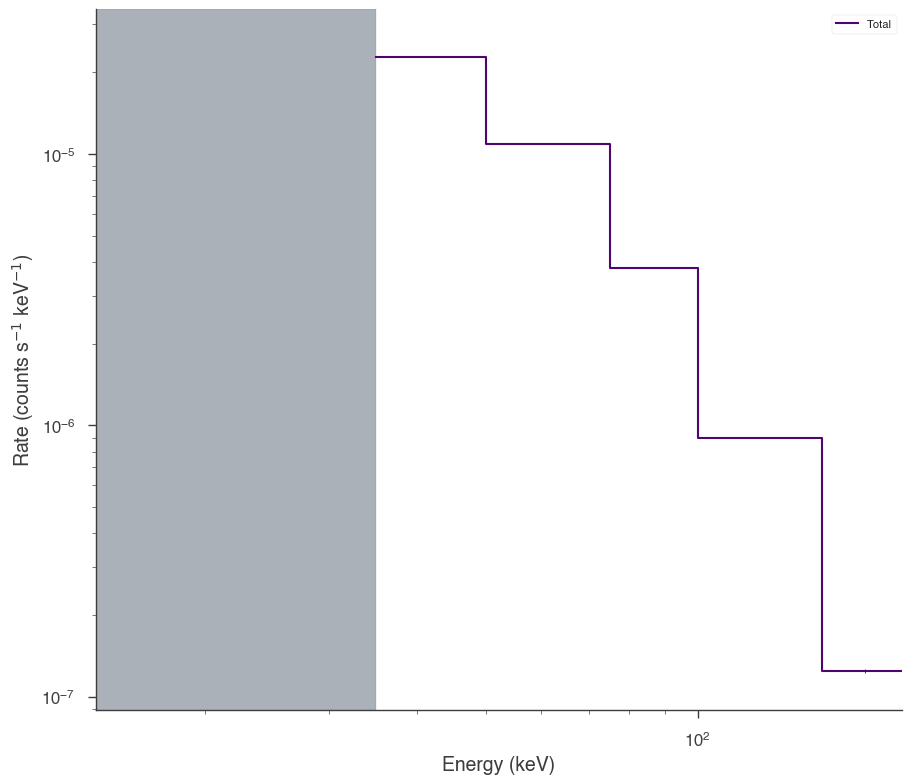

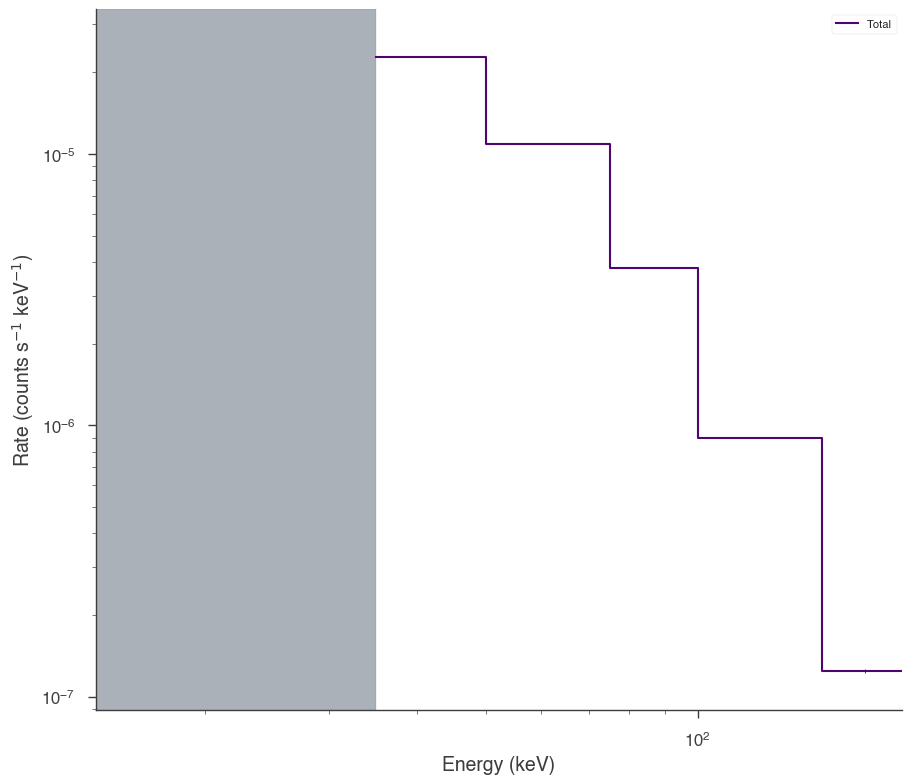

In [22]:
bat_rsp = data_path/"AGN_Data/XRay/Simulations/BAT_157m_swiftbat_survey_full_157m.rsp"
bat_pha = data_path/"AGN_Data/XRay/Simulations/simulate_bat_ec_200_gamma_1dot91.pha"

bat = OGIPLike("BAT", observation=bat_pha, response=bat_rsp)

bat.set_active_measurements("40-200")
bat.view_count_spectrum()

Load binned .hdf5 files

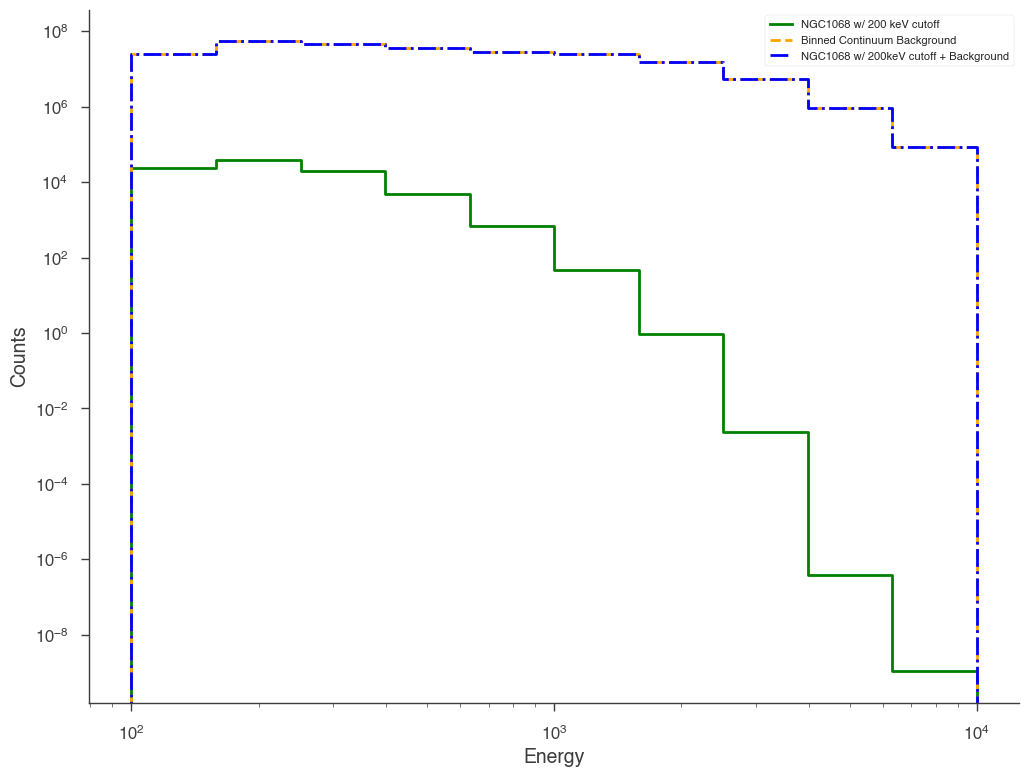

In [23]:
NGC1068_ec200 = Histogram.open(data_path/"AGN_Data/GammaRay/DC3/NGC_1068_ec200_corrected_COSI.hdf5")
bkg = Histogram.open(data_path / "DC3_Files/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5")
NGC1068_ec200_bkg = Histogram.open(data_path / "AGN_Data/GammaRay/DC3/NGC_1068_ec200_bkg_COSI.hdf5")

fig, ax = plt.subplots(figsize=(12, 9))
NGC1068_ec200.project("Em").draw(ax, label="NGC1068 w/ 200 keV cutoff", color="green")
bkg.project("Em").draw(ax, label="Binned Continuum Background", color="orange", linestyle="dashed")
NGC1068_ec200_bkg.project("Em").draw(ax, label="NGC1068 w/ 200keV cutoff + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

# ax.set_ylim(1e0, 1e8)
ax.set_ylabel("Counts")
ax.set_xlabel("Energy")
plt.legend()

Define the path to the detector response

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [60]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC1068_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

Define a point source at the known location with a Band function spectrum and add it to the model. The initial values of the Band function parameters are set to the true values used to simulate the source

### Powerlaw with energy cutoff fit

In [25]:
l=17.2
b=-51.9

# Give it some harsher initial guesses
K = 0.1 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = 10. * u.keV
index = -2.5

spectrum = Cutoff_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xc.value = xc.value
spectrum.index.value = index

# Harsher Parameters
spectrum.K.min_value = 1e-4
spectrum.K.max_value = 1
spectrum.xc.min_value = 1 # keep these relatively the same
spectrum.xc.max_value = 10000 # change to 1000
spectrum.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = 1

spectrum.K.delta = 0.05
spectrum.xc.delta = 10
spectrum.index.delta = 0.25

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xc.unit = xc.unit

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit

In [26]:
bat.use_effective_area_correction(0.2, 1.8)
plugins = DataList(bat, cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)
# nustar_fpma.use_effective_area_correction(0.2, 1.8)
# nustar_fpmb.use_effective_area_correction(0.2, 1.8)
# plugins = DataList(cosi, nustar_fpma, nustar_fpmb)
# plugins = DataList(cosi, bat, nustar_fpma, nustar_fpmb)
# plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit() #increase number of samples?

13:33:38 INFO      BAT is using effective area correction (between 0.2 and 1.8)                ]8;id=125189;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=494893;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#2279\2279]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=64820;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=368073;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(3.107 +/- 0.012) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.9147 +/- 0.0011,
source.spectrum.main.Cutoff_powerlaw.xc,(1.966 +/- 0.009) x 10^2,keV
cons_BAT,(9.82 +/- 0.04) x 10^-1,
background_cosi,(9.9995 +/- 0.0007) x 10^-1,


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
BAT,4.572673e-02
cosi,-1.556128e+09
total,-1.556128e+09


Values of statistical measures:

,statistical measures
AIC,0.000000e+00
BIC,-3.112257e+09


(                                                 value  negative_error  \
 source.spectrum.main.Cutoff_powerlaw.K        0.310673       -0.001250   
 source.spectrum.main.Cutoff_powerlaw.index   -1.914743       -0.001096   
 source.spectrum.main.Cutoff_powerlaw.xc     196.552372       -0.928183   
 cons_BAT                                      0.981985       -0.003683   
 background_cosi                               0.999948       -0.000063   
 
                                             positive_error     error  \
 source.spectrum.main.Cutoff_powerlaw.K            0.001167  0.001208   
 source.spectrum.main.Cutoff_powerlaw.index        0.001081  0.001089   
 source.spectrum.main.Cutoff_powerlaw.xc           0.927012  0.927598   
 cons_BAT                                          0.003873  0.003778   
 background_cosi                                   0.000065  0.000064   
 
                                                        unit  
 source.spectrum.main.Cutoff_powerlaw.K      

## Error propagation and plotting (Cutoff powerlaw function)

Define Band function spectrum injected into MEGAlib

In [27]:
K_inj = 3.1e-1 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.92

spectrum_inj_1068 = Cutoff_powerlaw()

spectrum_inj_1068.K.value = K_inj.value
spectrum_inj_1068.piv.value = piv_inj.value
spectrum_inj_1068.xc.value = xc_inj.value
spectrum_inj_1068.index.value = index_inj

spectrum_inj_1068.K.unit = K_inj.unit
spectrum_inj_1068.piv.unit = piv_inj.unit
spectrum_inj_1068.xc.unit = xc_inj.unit

The summary of the results above tell you the optimal values of the parameters, as well as the errors. Propogate the errors to the "evaluate_at" method of the spectrum

In [28]:
results_1068 = like.results

print(results_1068.display())

parameters = {par.name:results_1068.get_variates(par.path)
              for par in results_1068.optimized_model["source"].parameters.values()
              if par.free}

results_1068_err = results_1068.propagate(results_1068.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results_1068.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(3.107 +/- 0.012) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.9147 +/- 0.0011,
source.spectrum.main.Cutoff_powerlaw.xc,(1.966 +/- 0.009) x 10^2,keV
cons_BAT,(9.82 +/- 0.04) x 10^-1,
background_cosi,(9.9995 +/- 0.0007) x 10^-1,


Correlation matrix:

1.00,-0.44,0.21,-0.60,-0.02
-0.44,1.00,-0.69,-0.42,-0.00
0.21,-0.69,1.00,0.20,-0.02
-0.60,-0.42,0.20,1.00,0.02
-0.02,-0.00,-0.02,0.02,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
BAT,4.572673e-02
cosi,-1.556128e+09
total,-1.556128e+09


Values of statistical measures:

,statistical measures
AIC,0.000000e+00
BIC,-3.112257e+09


None
  * source (point source):
    * position:
      * l:
        * value: 17.2
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -51.9
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 0.3106734478926534
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 0.0001
            * max_value: 1.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.9147431875645289
      

Evaluate the flux and errors at a range of energies for the fitted and injected spectra, and the simulated source flux

In [29]:
energy_1068 = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_lo_1068 = np.zeros_like(energy)
flux_median_1068 = np.zeros_like(energy)
flux_hi_1068 = np.zeros_like(energy)
flux_inj_1068 = np.zeros_like(energy)

for i, e in enumerate(energy_1068):
    flux_1068 = results_1068_err(e)
    flux_median_1068[i] = flux_1068.median
    flux_lo_1068[i], flux_hi_1068[i] = flux_1068.equal_tail_interval(cl=0.68)
    flux_inj_1068[i] = spectrum_inj_1068.evaluate_at(e)

# Power law tail

In [61]:
# K_inj = 0.1*((3.1e-1)*100) / u.cm / u.cm / u.s / u.keV
K_inj = 0.1*spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
piv_inj = 1000. * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit


In [62]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_inj_ec200_PL = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_ec200_PL[i] = spectrum_inj_ec200_PL.evaluate_at(e)

In [63]:
# K_inj = 0.1*((3.1e-1)*100) / u.cm / u.cm / u.s / u.keV
K_inj = 0.1*spectrum_inj_1068.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
piv_inj = 1000. * u.keV
index_inj = -3.8

spectrum_inj_1068_PL = Powerlaw()

spectrum_inj_1068_PL.K.value = K_inj.value
spectrum_inj_1068_PL.piv.value = piv_inj.value
spectrum_inj_1068_PL.index.value = index_inj

spectrum_inj_1068_PL.K.unit = K_inj.unit
spectrum_inj_1068_PL.piv.unit = piv_inj.unit


In [64]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_inj_1068_PL = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_1068_PL[i] = spectrum_inj_1068_PL.evaluate_at(e)

In [65]:
K_inj = (spectrum_inj_ec1000.evaluate_at(3000)) / u.cm / u.cm / u.s / u.keV
piv_inj = 3000. * u.keV
index_inj = -2.1

spectrum_inj_ec1000_PL = Powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit

In [35]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_inj_ec1000_PL = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_ec1000_PL[i] = spectrum_inj_ec1000_PL.evaluate_at(e)

Plot the fitted and injected spectra

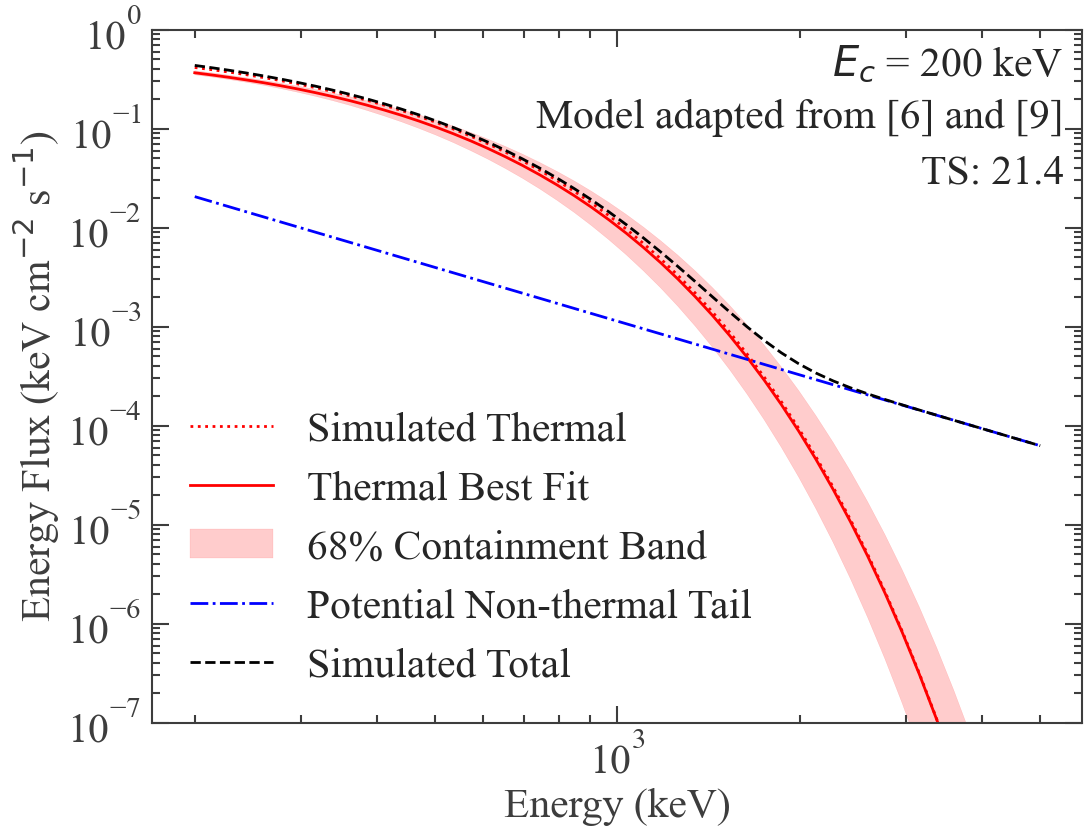

In [86]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9))

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

total_flux_ec200 = flux_inj_ec200 + flux_inj_ec200_PL
ax.plot(energy, energy*energy*flux_inj_ec200, color = 'red', ls = ":", label = "Simulated Thermal")
ax.plot(energy, energy*energy*flux_median_ec200, color = 'red', label = "Thermal Best Fit")
ax.fill_between(energy, energy*energy*flux_lo_ec200, energy*energy*flux_hi_ec200, alpha = .2, color = 'red', label = "68% Containment Band")
ax.plot(energy, energy*energy*flux_inj_ec200_PL, color = 'blue', ls = "-.", label = "Potential Non-thermal Tail")
ax.plot(energy, energy*energy*total_flux_ec200, color = 'black', ls = "--", label = "Simulated Total")
ax.set_ylim(1e-7, 1)
ax.text(
    0.98, 0.82,
    'TS: 21.4',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

# total_flux_ec1000 = flux_inj_ec1000 + flux_inj_ec1000_PL
# ax.plot(energy, energy*energy*flux_inj_ec1000, color = 'red', ls = ":", label = "Simulated Thermal")
# ax.plot(energy, energy*energy*flux_median_ec1000, color = 'red', label = "Thermal Best Fit")
# ax.fill_between(energy, energy*energy*flux_lo_ec1000, energy*energy*flux_hi_ec1000, alpha = .2, color = 'red', label = "68% Containment Band")
# ax.plot(energy, energy*energy*flux_inj_ec1000_PL, color = 'blue', ls = "-.", label = "Potential Non-thermal Tail")
# ax.plot(energy, energy*energy*total_flux_ec1000, color = 'black', ls = "--", label = "Simulated Total")
# ax.set_ylim(5e-3, 1)
# ax.text(
#     0.98, 0.82,
#     'TS: 35.8',
#     transform=ax.transAxes,
#     ha='right', va='top',
#     fontsize=FONT_SIZE,
#     fontweight='550'
# )

# NGC 1068
# total_flux_1068 = flux_inj_1068 + flux_inj_1068_PL
# ax.plot(energy, energy*energy*flux_inj_1068, color = 'red', ls = ":", label = "NGC 1068 Simulated")
# ax.plot(energy, energy*energy*flux_median_1068, color = 'red', label = "NGC 1068 Best Fit")
# ax.fill_between(energy, energy*energy*flux_lo_1068*(1/1.2), energy*energy*flux_hi_1068*1.2, alpha = .2, color = 'red', label = "NGC 1068 68% Containment Band")
# ax.plot(energy, energy*energy*flux_inj_1068_PL, color = 'blue', ls = "-.", label = "NGC 1068 Non-thermal Tail")
# ax.plot(energy, energy*energy*total_flux_1068, color = 'black', ls = "--", label = "NGC 1068 Total")
# ax.set_ylim(1e-6, 1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)
ax.text(
    0.98, 0.98,
    r'$E_c$ = 200 keV',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
ax.text(
    0.98, 0.90,
    'Model adapted from [6] and [9]',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
# ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False, ncols=2, columnspacing=0.5)
# ax.legend(fontsize=FONT_SIZE, loc='upper right', frameon=False)
ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

plt.savefig("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Proposals/SCSGC/SCSGC_Proposal/Plots/NGC4151_Fit_NonT_200_TimeCut.pdf")